LLE - Locally Linear Embedding: Nonlinear dimensionality reduction technique. Manifold learning technique that doesn't rely on projections, unlike PCA..and random projection.
- In a nutshell, LLE first determines how each training instance relates toits nearest neighbors, then it looks for a low dimensional representation of the training set where these local relationships are best preserved
- Approach makes it particularly good at unrolling twisted manifolds...especially when there is too much noise
- However, it does not scale well so its mostly for small to medium sized datasets...

Core idea of LLE:
- each point can be reconstructed as a linear combination of its nearest neighbors..
- If the data lies on a curved manifold, locally it looks approximately linear...

So, LLE:
 - Learns how each point depends on its neighbors
 - Finds the lower-dimensional embedding that preserves those dependencies...

Step 1: Find the nearest neighbors
 - For every point,
 - Find its k-nearest neighbors and only those neighbors will be used to reconstruct x in lower dimensional space

Step 2: Compute reconstruction weights:
- LLE now solves this optimization for each point: xi(in lower dim space) = sum of the product of reconstruction weights x neighbors

- Optimization is to minimize the reconstruction error between the computed x in lower dimensional space (product of weight mul and neighbors) and the original x in high dimensional space

- subject to the constraint that the sum of the reconstruction weights is equal to 1. (this makes the reconstruction translation invariant). 

Step 3: Find the low dimensional embedding:
- use the weights to compute the lower dimensional embedding...

Works because:
- algo preserves the local linear structure...
- Excellent for: smooth manifolds, high dimensional coordinates on a curved surface

Major pitfalls:
- neighbor selection is fragile: everything depends on nearest neighbors..if neighbors cross manifold boundaries - reconstruction is wrong
- sensitive to noise: cuz we are looking at minimising reconstruction distances so noise is gonna be a huge factor
- can't handle varying density: neighborhood sizes represent different geometry | reconstruction weights become inconsistent
- global structure is not preserved: LLE only preserves local reconstruction rules  | large scale geometry may distort | two distant regions can collapse together
- LLE was later replaced by UMAP -> 

In [1]:
from sklearn.datasets import make_swiss_roll
from sklearn.manifold import LocallyLinearEmbedding

In [2]:
X_swiss, t = make_swiss_roll(n_samples=1000, noise=0.2, random_state=42)

In [6]:
t.shape

(1000,)

In [3]:
X_swiss.shape

(1000, 3)

In [8]:
from matplotlib.colors import ListedColormap
import matplotlib.pyplot as plt
import numpy as np

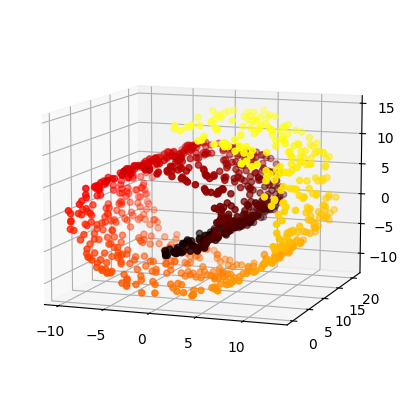

In [10]:
darker_hot = ListedColormap(plt.cm.hot(np.linspace(0, 0.8, 256)))

axes = [-11.5, 14, -2, 23, -12, 15]

fig = plt.figure(figsize=(6,5))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(X_swiss[:,0], X_swiss[:,1], X_swiss[:,2], c=t, cmap=darker_hot)
ax.view_init(10, -70)
plt.show()

In [11]:
lle = LocallyLinearEmbedding(n_components=2, n_neighbors=10, random_state=42)
X_unrolled = lle.fit_transform(X_swiss)

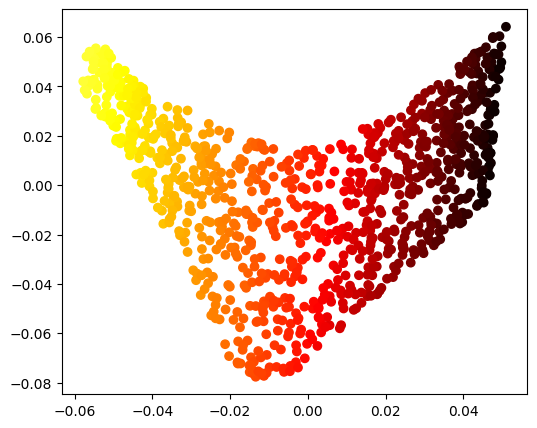

In [14]:
fig = plt.figure(figsize=(6,5))
ax = fig.add_subplot(111)

ax.scatter(X_unrolled [:,0], X_unrolled [:,1], c=t, cmap=darker_hot)

plt.show()

as can be seen, the swiss roll is completely unrolled...and the distances between instances are locally well preserved..however, distances are not preserved on a larger scale: the unrolled swiss roll should be a rectangle and not this stretched twisted band...
- LLE: for each training instance the algorithm identifies its k-nearest neighbors it then tries to reconstruct x as a linear function of these neighbors..more specifically, it tries to find the weights r

UMAP has displaced LLE and tSNE for visualisation tasks as its fsaster, more stable, and better preserves global structure. 

- Random Projection: best for speed and scalability with guarantees
- PCA: best when the structure is linear and u need scalability
- Kernel PCA: best when structure is non linear and n is manageable
- LLE/UMAP - best for visualisation of manifold structure
- Autoencoders: best with abundant data and need maximum flexibility

- UMAP and LLE are optimized for viz not preserving peoperties that clustering algos need
- This is the fundamental mismatch: they optimize for : make nearby points in high dim space nearby in low dim space
- they don't optimize for: preserving the relative distances and density structure that clustering algos rely on..


- **Specifically why UMAP hurts clustering:**
   - it artificially expands clusters: UMAP has param min_dist that controls how tightly points are packed in the embedding. by default, it spreads points out within clusters to make them visually readable. This means a tight dense cluster in high dim space becomes a diffuse spread out blob in the UMAP embedding. k-means or dbscan then sees a blob rather than a tight cluster and may split it or merge it with others
   - Distorts inter-cluster distances
   - Creates a false structure: **UMAP** can create apparent clusters in the embedding that do not exist in the original data. 
   - It is stochastic: run umap on 

Comparison: Is data linear/non-linear:
- 
### Practical Decision Tree
```
Start
  ↓
PCA explained variance — do 10 components capture >80%?
  ├── YES → data is linear → use PCA, done
  └── NO ↓
      Reconstruction error — does it plateau quickly?
        ├── YES → linear but high dimensional → more PCA components
        └── NO ↓
            Compare PCA vs KernelPCA on downstream task
              ├── Similar → linear methods sufficient
              └── KernelPCA much better ↓
                  Check intrinsic dimensionality
                    ├── Low intrinsic dim → nonlinear manifold → UMAP/KernelPCA
                    └── High intrinsic dim → genuinely complex data → autoencoder

non-linearity test:
- pythonfrom scipy.spatial.distance import pdist
from scipy.stats import spearmanr
import numpy as np

# Sample subset (full pairwise on 20k dims is expensive)
idx = np.random.choice(len(X), 500, replace=False)
X_sample = X[idx]

# Original pairwise distances
orig_dist = pdist(X_sample)

# PCA reduced pairwise distances
Z_pca = PCA(n_components=50).fit_transform(X_sample)
pca_dist = pdist(Z_pca)

# Correlation
corr, _ = spearmanr(orig_dist, pca_dist)
print(f"Distance preservation by PCA: {corr:.3f}")
```

**What to look for:**

- Correlation > 0.95 → PCA preserves distances well → linear
- Correlation < 0.85 → PCA distorting distances → nonlinear structure present

Discourse on why TSNE, UMAP, and LLE are not the best for downstream clustering tasks as they distort the local density and distances in the original data... hence failing for distance and density based clustering techniques...:
- https://stats.stackexchange.com/questions/263539/clustering-on-the-output-of-t-sne